In [1]:
library(pROC)
library(caret)
library(e1071)
library(RColorBrewer)
set.seed(42)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: lattice

Loading required package: ggplot2



In [2]:
meta<-read.csv('0122-metavalid.csv',header=F)

In [3]:
colnames(meta)<-c('ID','name','type')

In [4]:
meta

ID,name,type
<chr>,<chr>,<chr>
PUMCH217,陈云,AL
PUMCH003,解统珍,AL
PUMCH020,仲美英,AL
PUMCH131,苗运付,AL
PUMCH138,张秀芳,AL
PUMCH140,张启富,AL
PUMCH141,赵明东,AL
PUMCH144,张宝臣,AL
PUMCH150,王洪生,AL


In [5]:
rownames(meta)<-meta$ID

In [6]:
expr_df<-read.csv('0103-dbcsvxlswithnormaldensebygene.csv')

In [7]:
dim(expr_df)

[1] 370 369

In [8]:
expr_df$X<-NULL
rownames(expr_df)<-expr_df[,1]
expr_df<-expr_df[,-1]

In [9]:
length(intersect(rownames(meta),colnames(expr_df)))
dim(meta)
dim(expr_df)

[1] 367

[1] 433   3

[1] 370 367

In [10]:
meta2<-meta[colnames(expr_df),]

In [11]:
rownames(meta2)<-meta2$name

In [12]:
other<-read.csv('1117-otherPCD.csv')

In [13]:
meta2[other$name,]

,ID,name,type
,<chr>,<chr>,<chr>
NA,NA,NA,NA
NA.1,NA,NA,NA
NA.2,NA,NA,NA
NA.3,NA,NA,NA
NA.4,NA,NA,NA
NA.5,NA,NA,NA
NA.6,NA,NA,NA
NA.7,NA,NA,NA
NA.8,NA,NA,NA


In [14]:
expr_df$PUMCH217<-NULL
expr_df$PUMCH157<-NULL
expr_df$PUMCH085<-NULL

In [15]:
expr_df

,PUMCH001,PUMCH002,PUMCH003,PUMCH004,PUMCH010,PUMCH012,PUMCH013,PUMCH014,PUMCH015,PUMCH016,⋯,WUHAN51,WUHAN52,WUHAN53,WUHAN54,WUHAN55,WUHAN56,WUHAN57,WUHAN58,WUHAN59,WUHAN60
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
ACTG1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ADAMTS9,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ADAR,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
AHNAK2,1,0,1,1,0,0,0,0,1,0,⋯,0,0,0,0,0,2,0,0,2,0
AKT1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ANK2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
AP3B2,0,0,0,0,0,0,0,0,0,1,⋯,0,0,1,0,0,0,0,0,0,0
APC,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
APOBEC1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [16]:
expr_df2<-expr_df[c('KMT2D', 'RUNX1'),]

In [17]:
## number=5, 5-fold CV
## repeated ten times
fitControl <- trainControl(method = "repeatedcv",
                           number = 5,
                           repeats = 10,
                           ## Estimate class probabilities
                           classProbs = TRUE,
                           ## Evaluate performance using 
                           ## the following function
                           summaryFunction = twoClassSummary)

In [18]:
meta<-read.csv(file='0206-meta.csv')

In [19]:
metaMM<-meta[which(meta$type=='MM'),]
metaPOEMS<-meta[which(meta$type=='POEMS'),]
metaAL<-meta[which(meta$type=='AL'),]

In [20]:
expr_df2MM<-expr_df2[,metaMM$X]
expr_df2POEMS<-expr_df2[,metaPOEMS$X]
expr_df2AL<-expr_df2[,metaAL$X]

In [21]:
expr_df2MM<-as.data.frame(t(expr_df2MM))
expr_df2POEMS<-as.data.frame(t(expr_df2POEMS))
expr_df2AL<-as.data.frame(t(expr_df2AL))

In [22]:
expr_df2MM<-cbind(expr_df2MM,metaMM$group)
expr_df2POEMS<-cbind(expr_df2POEMS,metaPOEMS$group)
expr_df2AL<-cbind(expr_df2AL,metaAL$group)

In [23]:
colnames(expr_df2MM)[3]<-'Y'
colnames(expr_df2AL)[3]<-'Y'
colnames(expr_df2POEMS)[3]<-'Y'

In [24]:
# randomly sample 50% of the row IDs for training; the remaining 50% serve as validation
train.rows <- sample(rownames(expr_df2MM), dim(expr_df2MM)[1]*0.5)

# collect all the columns with training row ID into training set:
matrix3t.train <- expr_df2MM[train.rows, ]

# assign row IDs that are not already in the training set, into validation
valid.rows <- setdiff(rownames(expr_df2MM), train.rows)
matrix3t.valid <- expr_df2MM[valid.rows, ]



In [25]:
svmFit <- train(Y ~ ., data=matrix3t.train, 
                method = "svmRadial", 
                trControl = fitControl, 
                #          preProc = c("center", "scale"),
                tuneLength = 10,
                metric = "ROC")

In [26]:
train.pred <- predict(svmFit,matrix3t.train)
validation.pred <- predict(svmFit,matrix3t.valid)

In [27]:
tpred <- predict(svmFit,matrix3t.train, type = 'prob')
vpred <- predict(svmFit,matrix3t.valid, type = 'prob')
train.con <- confusionMatrix(train.pred, factor(matrix3t.train$Y))
valid.con <- confusionMatrix(validation.pred, factor(matrix3t.valid$Y))

In [28]:
train.con
valid.con 

Confusion Matrix and Statistics

          Reference
Prediction group1 group2
    group1     21      1
    group2      2     57
                                          
               Accuracy : 0.963           
                 95% CI : (0.8956, 0.9923)
    No Information Rate : 0.716           
    P-Value [Acc > NIR] : 1.044e-08       
                                          
                  Kappa : 0.9077          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.9130          
            Specificity : 0.9828          
         Pos Pred Value : 0.9545          
         Neg Pred Value : 0.9661          
             Prevalence : 0.2840          
         Detection Rate : 0.2593          
   Detection Prevalence : 0.2716          
      Balanced Accuracy : 0.9479          
                                          
       'Positive' Class : group1          
            

Confusion Matrix and Statistics

          Reference
Prediction group1 group2
    group1     23      2
    group2      1     56
                                          
               Accuracy : 0.9634          
                 95% CI : (0.8968, 0.9924)
    No Information Rate : 0.7073          
    P-Value [Acc > NIR] : 3.205e-09       
                                          
                  Kappa : 0.9127          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.9583          
            Specificity : 0.9655          
         Pos Pred Value : 0.9200          
         Neg Pred Value : 0.9825          
             Prevalence : 0.2927          
         Detection Rate : 0.2805          
   Detection Prevalence : 0.3049          
      Balanced Accuracy : 0.9619          
                                          
       'Positive' Class : group1          
            

In [29]:
testing.pred1 <- predict(svmFit,expr_df2AL)
spred1 <- predict(svmFit,expr_df2AL, type = 'prob')
testing.con1 <- confusionMatrix(testing.pred1, factor(expr_df2AL$Y))

In [30]:
testing.pred2 <- predict(svmFit,expr_df2POEMS)
spred2 <- predict(svmFit,expr_df2POEMS, type = 'prob')
testing.con2 <- confusionMatrix(testing.pred2, factor(expr_df2POEMS$Y))

In [31]:
testing.con1
testing.con2

Confusion Matrix and Statistics

          Reference
Prediction group1 group2
    group1     23      1
    group2      1     96
                                         
               Accuracy : 0.9835         
                 95% CI : (0.9416, 0.998)
    No Information Rate : 0.8017         
    P-Value [Acc > NIR] : 1.147e-09      
                                         
                  Kappa : 0.948          
                                         
 Mcnemar's Test P-Value : 1              
                                         
            Sensitivity : 0.9583         
            Specificity : 0.9897         
         Pos Pred Value : 0.9583         
         Neg Pred Value : 0.9897         
             Prevalence : 0.1983         
         Detection Rate : 0.1901         
   Detection Prevalence : 0.1983         
      Balanced Accuracy : 0.9740         
                                         
       'Positive' Class : group1         
                                

Confusion Matrix and Statistics

          Reference
Prediction group1 group2
    group1     25      1
    group2      0     41
                                          
               Accuracy : 0.9851          
                 95% CI : (0.9196, 0.9996)
    No Information Rate : 0.6269          
    P-Value [Acc > NIR] : 1.052e-12       
                                          
                  Kappa : 0.9684          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 1.0000          
            Specificity : 0.9762          
         Pos Pred Value : 0.9615          
         Neg Pred Value : 1.0000          
             Prevalence : 0.3731          
         Detection Rate : 0.3731          
   Detection Prevalence : 0.3881          
      Balanced Accuracy : 0.9881          
                                          
       'Positive' Class : group1          
            

Setting levels: control = group1, case = group2

Setting direction: controls > cases

Setting levels: control = group1, case = group2

Setting direction: controls > cases

Setting levels: control = group1, case = group2

Setting direction: controls > cases

Setting levels: control = group1, case = group2

Setting direction: controls > cases



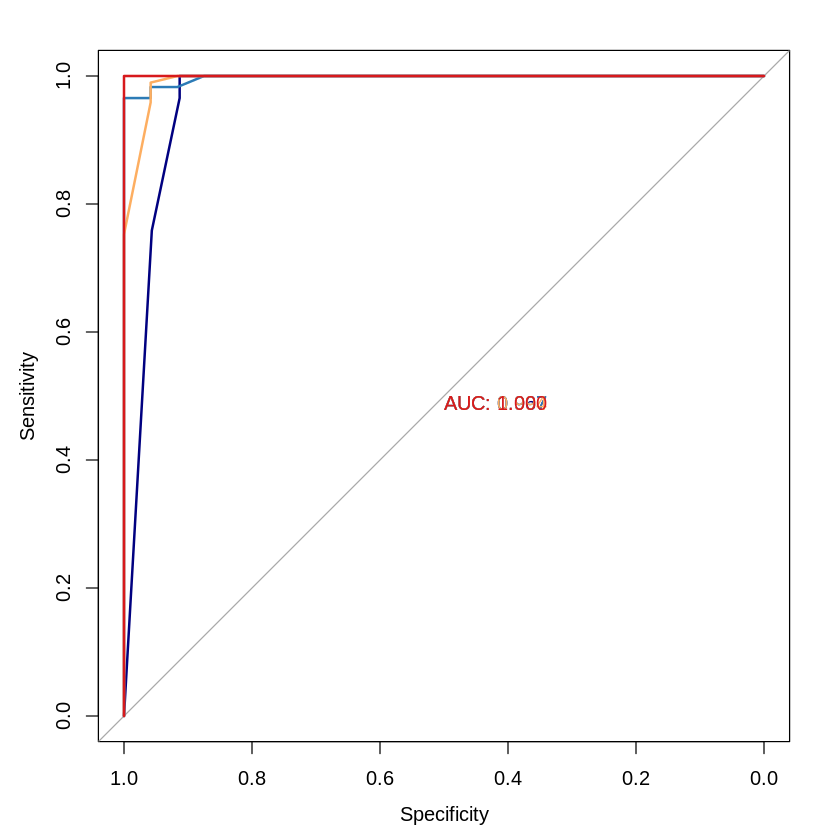

In [32]:
roc2<-roc(matrix3t.train$Y,tpred[,1])
plot.roc(roc2,col="navy",print.auc =TRUE,print.auc.col = "navy")
roc1<-roc(matrix3t.valid$Y,vpred[,1])
plot.roc(roc1,col=brewer.pal(4,'RdYlBu')[4],print.auc =TRUE,print.auc.col = brewer.pal(4,'RdYlBu')[4],add=TRUE)
roc3<-roc(expr_df2AL$Y,spred1[,1])
plot.roc(roc3,col=brewer.pal(4,'RdYlBu')[2],print.auc =TRUE,print.auc.col =brewer.pal(4,'RdYlBu')[2],add=TRUE)
roc4<-roc(expr_df2POEMS$Y,spred2[,1])
plot.roc(roc4,col=brewer.pal(4,'RdYlBu')[1],print.auc =TRUE,print.auc.col = brewer.pal(4,'RdYlBu')[1],add=TRUE)

In [33]:
pdf("SVM.pdf",width=5,height=5)
roc2<-roc(matrix3t.train$Y,tpred[,1])
plot.roc(roc2,col="navy",print.auc =TRUE,print.auc.col = "navy")
roc1<-roc(matrix3t.valid$Y,vpred[,1])
plot.roc(roc1,col=brewer.pal(4,'RdYlBu')[4],print.auc =TRUE,print.auc.col = brewer.pal(4,'RdYlBu')[4],add=TRUE)
roc3<-roc(expr_df2AL$Y,spred1[,1])
plot.roc(roc3,col=brewer.pal(4,'RdYlBu')[2],print.auc =TRUE,print.auc.col =brewer.pal(4,'RdYlBu')[2],add=TRUE)
roc4<-roc(expr_df2POEMS$Y,spred2[,1])
plot.roc(roc4,col=brewer.pal(4,'RdYlBu')[1],print.auc =TRUE,print.auc.col = brewer.pal(4,'RdYlBu')[1],add=TRUE)
dev.off()

Setting levels: control = group1, case = group2

Setting direction: controls > cases

Setting levels: control = group1, case = group2

Setting direction: controls > cases

Setting levels: control = group1, case = group2

Setting direction: controls > cases

Setting levels: control = group1, case = group2

Setting direction: controls > cases



png 
  2

In [40]:
svmFit

Support Vector Machines with Radial Basis Function Kernel 

81 samples
 2 predictor
 2 classes: 'group1', 'group2' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 10 times) 
Summary of sample sizes: 66, 65, 65, 64, 64, 65, ... 
Resampling results across tuning parameters:

  C       ROC        Sens   Spec     
    0.25  0.9590644  0.911  0.9825758
    0.50  0.9549356  0.911  0.9825758
    1.00  0.9510189  0.911  0.9825758
    2.00  0.9566553  0.911  0.9965152
    4.00  0.9565417  0.911  0.9965152
    8.00  0.9566553  0.911  0.9983333
   16.00  0.9572008  0.911  0.9983333
   32.00  0.9586326  0.911  0.9983333
   64.00  0.9569886  0.911  0.9983333
  128.00  0.9577689  0.911  0.9983333

Tuning parameter 'sigma' was held constant at a value of 2.13089
ROC was used to select the optimal model using the largest value.
The final values used for the model were sigma = 2.13089 and C = 0.25.

In [195]:
compare<-matrix(c(10,15,5,17),nr=2,dimnames=list(c('group1','group2'),c('aboveVGPR','belowVGPR')))
compare
fisher.test(compare)
chisq.test(compare,correct=FALSE)
chisq.test(compare)

,aboveVGPR,belowVGPR
group1,10,5
group2,15,17



	Fisher's Exact Test for Count Data

data:  compare
p-value = 0.2301
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  0.5408765 10.3227461
sample estimates:
odds ratio 
  2.227363 



	Pearson's Chi-squared test

data:  compare
X-squared = 1.6067, df = 1, p-value = 0.205



	Pearson's Chi-squared test with Yates' continuity correction

data:  compare
X-squared = 0.91014, df = 1, p-value = 0.3401
